In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mplhep
import sys
from sklearn.decomposition import PCA
from typing import List, Optional
import timeit
import awkward as ak
import torch
import torch.nn as nn
from torch.nn import Parameter 
from torch.nn.init import xavier_uniform_, xavier_normal_, constant_
import torch
from torch import nn, Tensor
from typing import Optional
import torch.nn.functional as F
from typing import Optional, Tuple
_is_fastpath_enabled: bool = True
from torch.overrides import (
    handle_torch_function,
    has_torch_function,
    has_torch_function_unary,
    has_torch_function_variadic,
)
linear = torch._C._nn.linear
import math
import random
import warnings
import copy
from torch._C import _add_docstr, _infer_size
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colorbar import ColorbarBase
from matplotlib.cm import ScalarMappable

from functools import partial
from weaver.utils.logger import _logger
import os
import uproot
from torch.utils.data import IterableDataset, DataLoader
import numpy as np
from tqdm import tqdm
from torch._torch_docs import reproducibility_notes, sparse_support_notes, tf32_notes

import subprocess
import sys
sys.path.append('../')
import model_utils as mu

In [2]:
# access data from local .npys 

qgtrained_modelpath = '../../models/on-qg-run2_best_epoch_state.pt'
tltrained_modelpath = '../../models/on-tl-run4_best_epoch_state.pt'
jc_kintrained_modelpath = '../../models/ParT_kin.pt'
jc_fulltrained_modelpath = './models/ParT_full.pt'
jc_ablated_modelpath = './models/JetClass_ParT_zeroed_interaction.pt'
jc_argmax_modelpath = './models/argmax-ParT-10M.pt'

In [3]:
features, labels, mask, points, vectors = mu.load_jet_data(0, 50, feats='full', data_dir='./jc_full_data/')

In [4]:
jc_full_model = mu.get_model('jc_full')

jc_full_hooks = mu.ParT_Hook(model=jc_full_model)

num_heads = jc_full_hooks.kwargs['num_heads']
num_layers = jc_full_hooks.kwargs['num_layers']

# JC full model loading and inference

jc_full_state_dict = torch.load(jc_ablated_modelpath, map_location=torch.device('cpu'))
jc_full_model.load_state_dict(jc_full_state_dict)
jc_full_model.eval()
with torch.no_grad():
    jc_full_y_pred= jc_full_model(torch.from_numpy(points),torch.from_numpy(features),
                                  torch.from_numpy(vectors),torch.from_numpy(mask))
jc_full_attention = jc_full_model.get_attention_matrix()
jc_full_interaction = jc_full_model.get_interactionMatrix()

print('JC Full done!')

Registered hooks onto attention modules
Registered hooks onto attention modules
Registered hooks onto attention modules
Registered hooks onto attention modules
Registered hooks onto attention modules
Registered hooks onto attention modules
Registered hooks onto attention modules
Registered hooks onto attention modules


/home/tim_legge/Interpreting-Particle-Transformers/model_utils.py:1800: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.use_amp):
/home/tim_legge/Interpreting-Particle-Transformers/model_utils.py:576: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


JC Full done!


In [13]:
pad_limits = jc_full_hooks.cut_padding(jc_full_hooks.pre_softmax_attentions, mask)
pre_softmax_attn = jc_full_hooks.pre_softmax_attentions
pre_softmax_inter = jc_full_hooks.pre_softmax_interactions

# first layer softmaxed matrices
softmax_qk_attn = [[[torch.softmax(pre_softmax_attn[l][i][j, :pad_limits[i], :pad_limits[i]], dim=-1) for j in range(len(pre_softmax_attn[0][0]))] for i in range(len(pre_softmax_attn[0]))] for l in range(num_layers)]
softmax_full_attn = [[[torch.softmax(pre_softmax_attn[l][i][j, :pad_limits[i], :pad_limits[i]] + pre_softmax_inter[0][i][j, :pad_limits[i], :pad_limits[i]], dim=-1) for j in range(len(pre_softmax_inter[0][0]))] for i in range(len(pre_softmax_inter[0]))] for l in range(num_layers)]

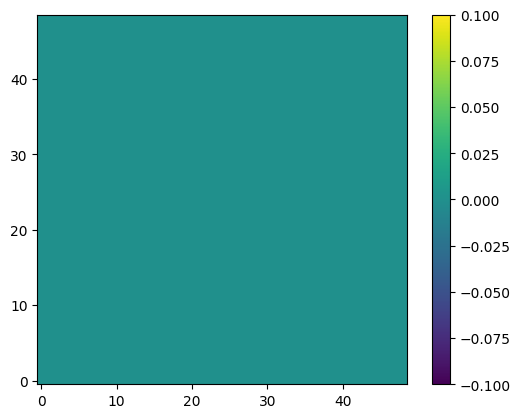

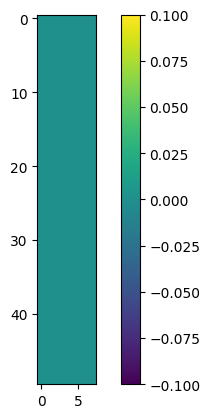

In [21]:
jet = 8
head = 0
layer = 1

diff_maps = [[[torch.abs(softmax_full_attn[l][i][j] - softmax_qk_attn[l][i][j]) for j in range(len(pre_softmax_inter[0][0]))] for i in range(len(pre_softmax_inter[0]))] for l in range(num_layers)]
# total diff by head
total_diff = [[[torch.sum(diff_maps[l][i][j]) for j in range(len(pre_softmax_inter[0][0]))] for i in range(len(pre_softmax_inter[0]))] for l in range(num_layers)]

plt.imshow(diff_maps[layer][jet][head].numpy(), origin='lower', cmap='viridis')
plt.colorbar()
plt.show()

plt.imshow(total_diff[layer][:][:])
plt.colorbar()
plt.show()

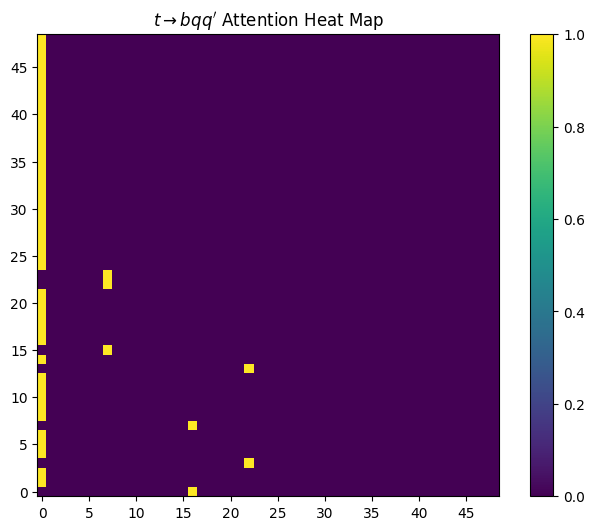

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming the following variables are already defined
# Example dummy data for context:
# attention = np.random.rand(12, 128, 64, 64)  # A random tensor for illustration purposes
# num = 50  # You can replace this with your actual value

# Plotting the attention matrix with the origin in the lower left
plt.figure(figsize=(8, 6))  # Adjust figure size as needed

jet = 8
layer = 0
head = 0

# Visualizing a specific part of the attention matrix
plt.imshow(jc_full_attention[layer][jet][head, 0:pad_limits[jet], 0:pad_limits[jet]], origin='lower', cmap='viridis')

# Adding colorbar
plt.colorbar()

# Set the x and y ticks to integer values
plt.xticks(np.arange(0, pad_limits[jet], step=5))  # Set x-axis ticks as integers with step size of 5
plt.yticks(np.arange(0, pad_limits[jet], step=5))  # Same for y-axis
plt.title(r'$t \rightarrow bqq^{\prime}$ Attention Heat Map')

# Using LaTeX for the title in particle decay process format

# Save the plot to a file
#plt.savefig('/content/drive/MyDrive/networks/Plots/HeatmapTbqq.pdf', bbox_inches="tight")

# Show the plot
plt.show()


/tmp/ipykernel_96622/1298284733.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pre_attn = torch.tensor(jc_full_hooks.pre_softmax_attentions[layer][jet][head, 0:pad_limits[jet], 0:pad_limits[jet]] + jc_full_hooks.pre_softmax_interactions[layer][jet][head, 0:pad_limits[jet], 0:pad_limits[jet]])


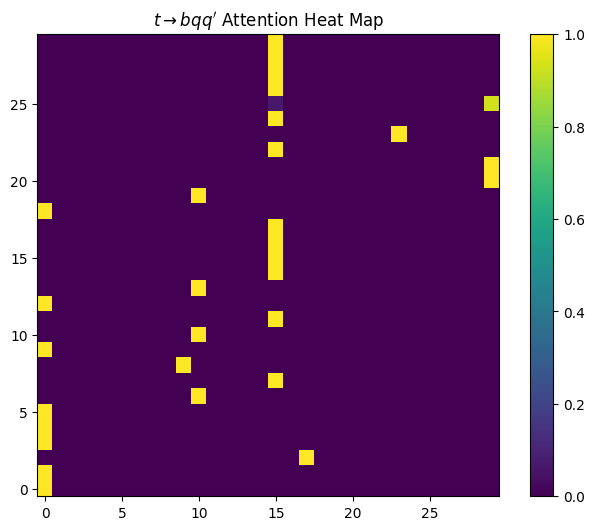

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming the following variables are already defined
# Example dummy data for context:
# attention = np.random.rand(12, 128, 64, 64)  # A random tensor for illustration purposes
# num = 50  # You can replace this with your actual value

# Plotting the attention matrix with the origin in the lower left
plt.figure(figsize=(8, 6))  # Adjust figure size as needed

jet = 1
layer = 0
head = 3

# independent softmax computation to check validity
pre_attn = torch.tensor(jc_full_hooks.pre_softmax_attentions[layer][jet][head, 0:pad_limits[jet], 0:pad_limits[jet]] + jc_full_hooks.pre_softmax_interactions[layer][jet][head, 0:pad_limits[jet], 0:pad_limits[jet]])
should_be_same = torch.softmax(pre_attn, dim=-1)
heatmap_sparse = should_be_same.numpy()
# Visualizing a specific part of the attention matrix
plt.imshow(should_be_same.numpy(), origin='lower', cmap='viridis')

# Adding colorbar
plt.colorbar()

# Set the x and y ticks to integer values
plt.xticks(np.arange(0, pad_limits[jet], step=5))  # Set x-axis ticks as integers with step size of 5
plt.yticks(np.arange(0, pad_limits[jet], step=5))  # Same for y-axis
plt.title(r'$t \rightarrow bqq^{\prime}$ Attention Heat Map')

# Using LaTeX for the title in particle decay process format

# Save the plot to a file
#plt.savefig('/content/drive/MyDrive/networks/Plots/HeatmapTbqq.pdf', bbox_inches="tight")

# Show the plot
plt.show()


In [ ]:
# Get attention dists for every head in the model to see if nonbinary behavior crops up

# Define number of bins for the probability distribution
num_bins = 20

# Define the bin edges between 0 and 1, using 20 evenly spaced bins
bin_edges = np.linspace(0, 1, num_bins + 1)

def process_in_chunks(attention_iterator, chunk_size=100000, bin_edges=bin_edges):
    hist_counts = np.zeros(len(bin_edges) - 1)  # Initialize histogram counts for bins

    # Process each chunk of attention data
    for chunk in attention_iterator:
        # Flatten the chunk to ensure it's 1D and processable by np.histogram
        chunk = np.array(chunk).flatten()

        # Calculate histogram for this chunk
        hist, _ = np.histogram(chunk, bins=bin_edges)

        # Accumulate the counts
        hist_counts += hist

    total_data_points = hist_counts.sum()  # Total number of points processed
    probabilities = hist_counts / total_data_points  # Normalize to get probabilities
    return probabilities

# Simulate loading a large dataset in chunks (e.g., from a file or other source)
def attention_generator(attention, chunk_size):
    """Simulate chunked data loader for large dataset."""
    for i in range(0, len(attention), chunk_size):
        yield attention[i:i + chunk_size]

# initialize IBI counter
ibi_counter = np.zeros((num_layers, num_heads))

# track all tokens of all jets
ibi_tracker = np.zeros((howmanyjets, 128))

# nonbinary tracker
nb_counter = np.zeros((num_layers, num_heads))
nb_tracker = np.zeros((howmanyjets, 128))
nb_proportions = np.zeros((1,128))

print(jc_full_attention[0][:][0,:,:].shape)

for layer in range(num_layers):
    for head in range(num_heads):

        # track cases where interaction term is higher than highest trad attention term (identified by interaction, IBI)
        per_head_pre_attention = jc_full_hooks.pre_softmax_attentions[layer,:,head, :, :]
        per_head_pre_interaction = jc_full_hooks.pre_softmax_interactions[layer,:,head, :, :]
        per_head_softmaxed = torch.softmax(torch.tensor(per_head_pre_attention + per_head_pre_interaction), dim=-1).numpy()

        # finding what the largest attention vs interaction scores were
        for jet in range(howmanyjets):
            for token in range(pad_limits[jet]):

                # gauge binary-ness of each row update

                if max(per_head_softmaxed[jet][token,:]) <= 0.8:
                    if np.sum(nb_counter) == 0:
                        nb_proportions[0] = per_head_softmaxed[jet][token,:]
                    else:
                        nb_proportions = np.vstack((nb_proportions, per_head_softmaxed[jet][token,:]))
                    nb_counter[layer][head] += 1
                    nb_tracker[jet][token] = 1

                max_attn_idx = np.argmax(per_head_pre_attention[jet][token,:]), 
                max_attn = max(per_head_pre_attention[jet][token,:])
                max_inter_idx = np.argmax(per_head_pre_interaction[jet][token,:])
                max_inter = max(per_head_pre_interaction[jet][token,:])
                if max_attn_idx != max_inter_idx and max_inter+per_head_pre_attention[jet][token,max_inter_idx] >= max_attn+per_head_pre_interaction[jet][token,max_inter_idx]:
                   ibi_counter[layer][head] += 1
                   ibi_tracker[jet][token] = 1

In [ ]:
total_nb = np.sum(nb_counter)
print(f'Total Non-Binary Attention Rows: {total_nb}')

print(nb_counter)

In [ ]:
total_rows = np.sum(pad_limits)*num_layers*num_heads
print(f'Total Attention Rows Processed: {total_rows}')
print(f'Proportion of Non-Binary Attention Rows: {total_nb/total_rows}')

In [ ]:
# Reading IBI data

total_token_updates = num_heads*num_layers*np.sum(pad_limits)
ibi_per_token = np.sum(ibi_counter) / total_token_updates

# mask out padded vals from ibi_tracker

total_tokens = np.sum(pad_limits)
ibi_tokens = 0

for jet_idx, jet in enumerate(ibi_tracker):
    ibi_tokens += np.sum(jet[:pad_limits[jet_idx]])

frac_of_ibi_tokens = ibi_tokens / total_tokens

In [ ]:
print(f'Total token updates: {total_token_updates}, Total IBIs: {np.sum(ibi_counter)}')
print(f'IBI per token: {ibi_per_token}')
print(f'Total tokens: {total_tokens}, tokens to encounter IBI: {ibi_tokens}')
print(f'Fraction of tokens to encounter IBI: {frac_of_ibi_tokens}')

In [ ]:
# plotting nonbinary rows

plt.figure(figsize=(10, 8))  # Adjust figure size as needed

plt.imshow(nb_proportions[:100,0:128], origin='lower', cmap='viridis', aspect='auto')
plt.colorbar()
plt.title('Non-Binary Attention Row Tracker (First 100 Instances)')

In [ ]:
for layer in range(num_layers):
    for head in range(num_heads):

        # track cases where interaction term is higher than highest trad attention term (identified by interaction, IBI)
        per_head_pre_attention = jc_full_hooks.pre_softmax_attentions[layer,:,head, :, :]
        per_head_pre_interaction = jc_full_hooks.pre_softmax_interactions[layer,:,head, :, :]
        per_head_softmaxed = torch.softmax(torch.tensor(per_head_pre_attention + per_head_pre_interaction), dim=-1).numpy()


        flattened_attention = per_head_softmaxed.flatten()

        # Process the data in chunks (using a generator)
        probabilities = process_in_chunks(attention_generator(flattened_attention, chunk_size=100000))

        # Manually set the bin centers to have equal bar spacing
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Calculate the centers of each bin
        equal_width = bin_edges[1] - bin_edges[0]  # Set equal width for all bars based on bin spacing

        # Create figure and axes
        fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

        # Plot bar graph with equal-width bars
        ax.bar(bin_centers, probabilities, width=equal_width, log=False)  # No log scale for clearer visualization

        # Set custom x-tick locations and labels (optional)
        #ax.set_xticks(bin_centers, 0.1)
        #ax.set_xticklabels([f'{edge:.2f}' for edge in bin_centers], fontsize=10, fontweight='bold')

        # Set x and y axis labels
        ax.set_xlabel('Attention Score', fontsize=14)
        ax.set_ylabel('Probability', fontsize=14)
        plt.yscale('log')

        # Add a title
        ax.set_title(f'JetClass Attention Distribution - Layer {layer}, Head {head}', fontsize=16)
        plt.savefig(f'./checking_binary_attention/dist_layer{layer}_head{head}.pdf', bbox_inches="tight")

        # Show the plot
        plt.show()


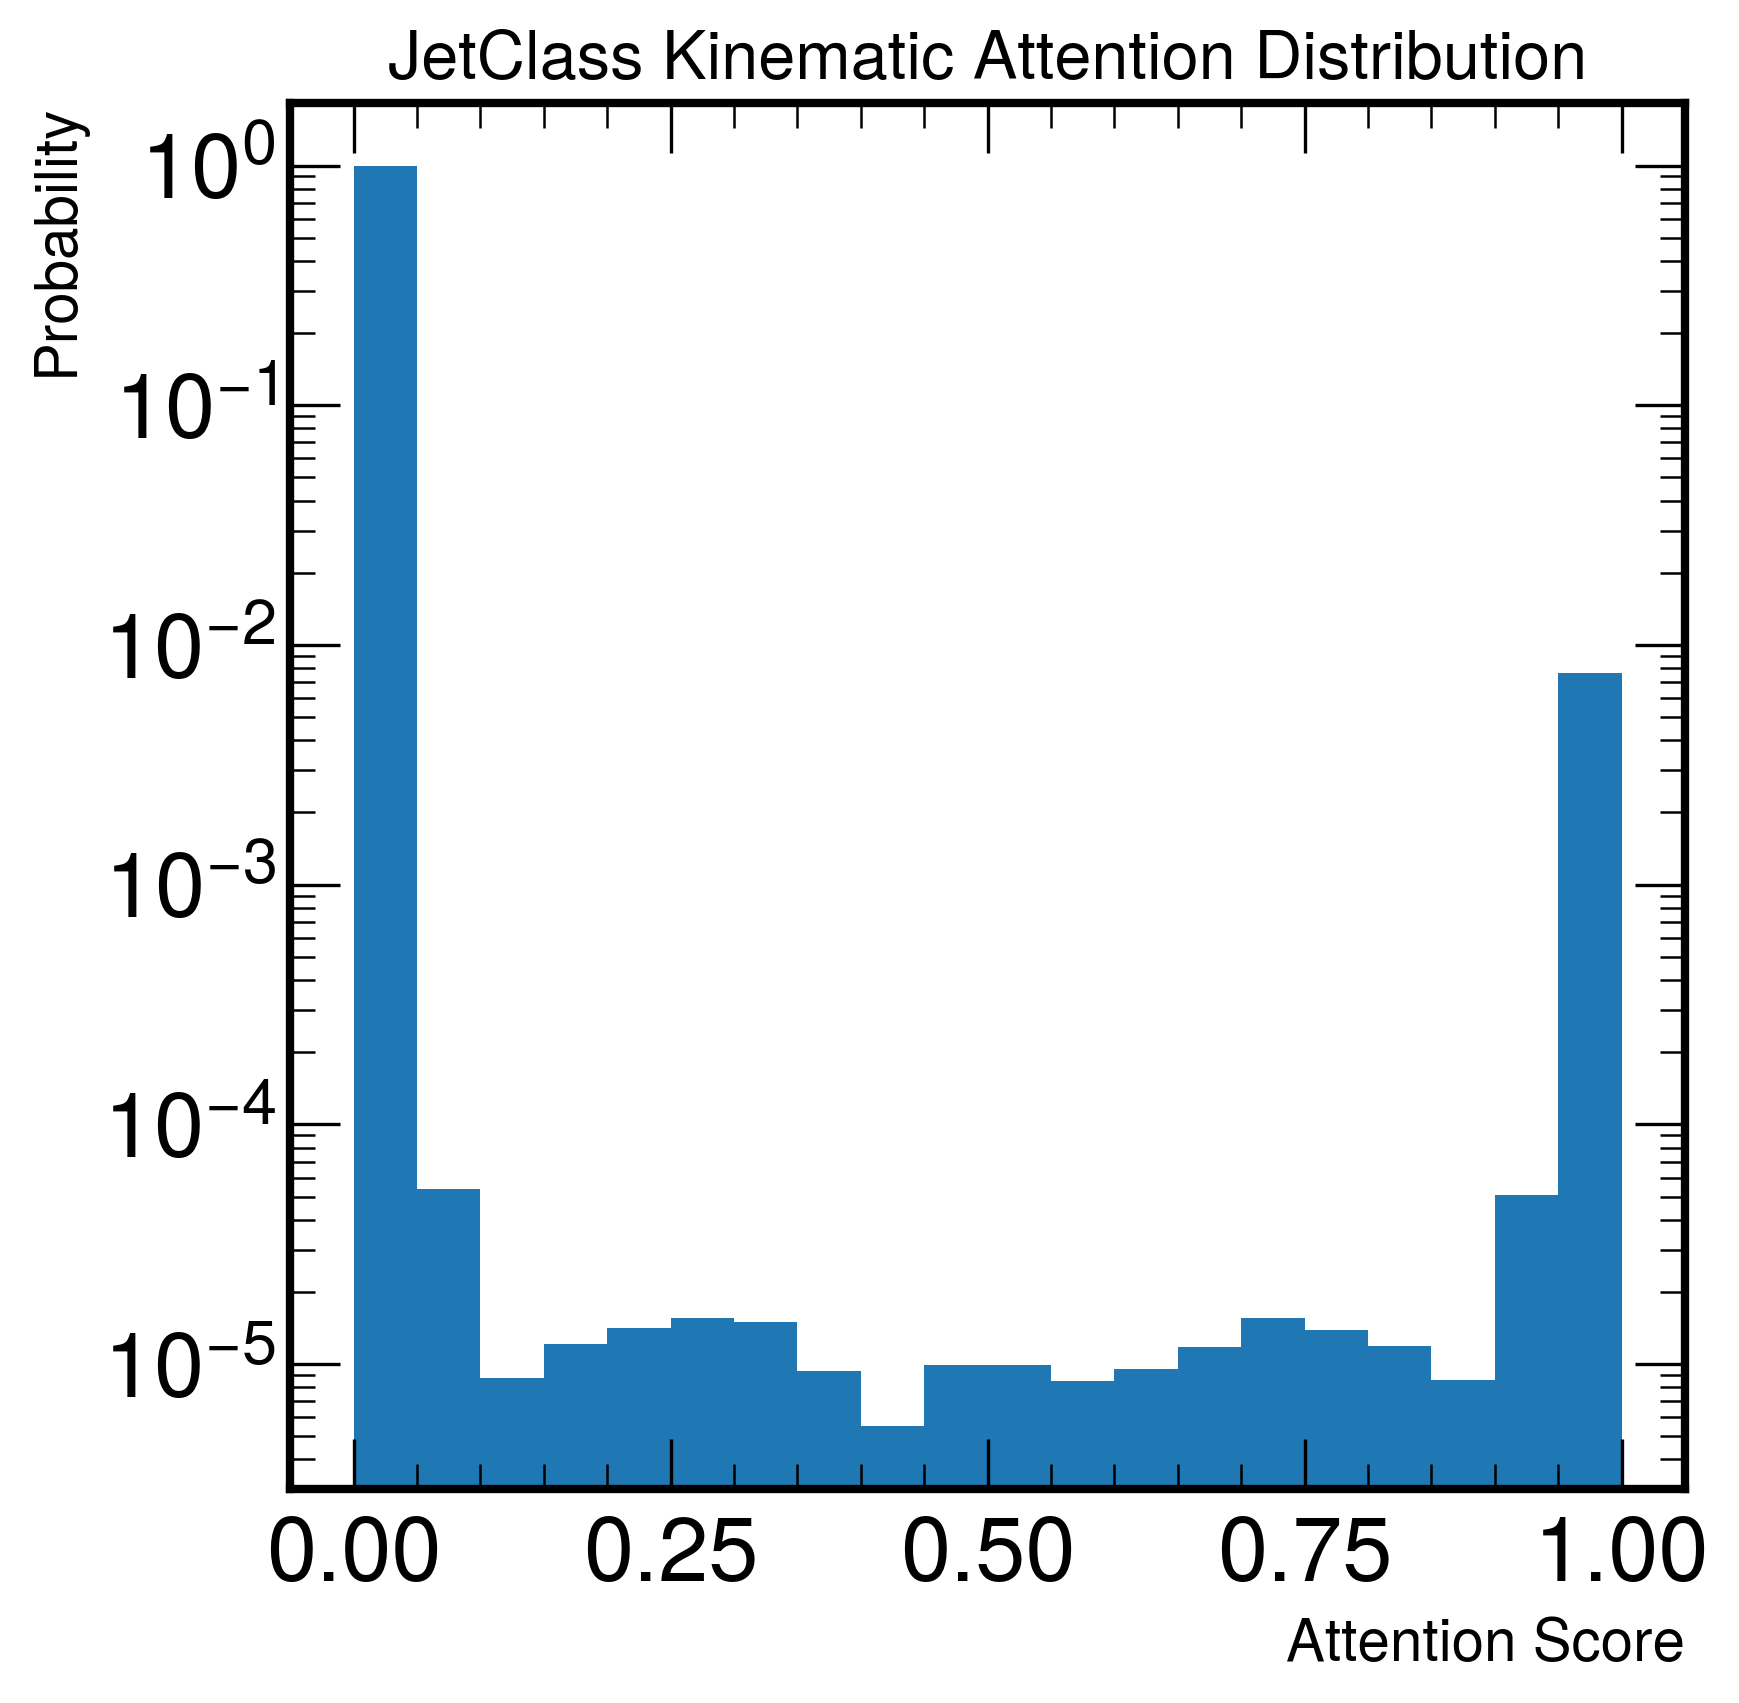

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#running for qg-trained model first

# Assuming attention is already a list or array
# Flattening the attention array
flattened_attention = np.stack(jc_full_attention).flatten()

# Define number of bins for the probability distribution
num_bins = 20

# Define the bin edges between 0 and 1, using 20 evenly spaced bins
bin_edges = np.linspace(0, 1, num_bins + 1)

# Function to process data in chunks and compute histogram
def process_in_chunks(attention_iterator, chunk_size=100000, bin_edges=bin_edges):
    hist_counts = np.zeros(len(bin_edges) - 1)  # Initialize histogram counts for bins

    # Process each chunk of attention data
    for chunk in attention_iterator:
        # Flatten the chunk to ensure it's 1D and processable by np.histogram
        chunk = np.array(chunk).flatten()

        # Calculate histogram for this chunk
        hist, _ = np.histogram(chunk, bins=bin_edges)

        # Accumulate the counts
        hist_counts += hist

    total_data_points = hist_counts.sum()  # Total number of points processed
    probabilities = hist_counts / total_data_points  # Normalize to get probabilities
    return probabilities

# Simulate loading a large dataset in chunks (e.g., from a file or other source)
def attention_generator(attention, chunk_size):
    """Simulate chunked data loader for large dataset."""
    for i in range(0, len(attention), chunk_size):
        yield attention[i:i + chunk_size]

# Process the data in chunks (using a generator)
probabilities = process_in_chunks(attention_generator(flattened_attention, chunk_size=100000))

# Manually set the bin centers to have equal bar spacing
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Calculate the centers of each bin
equal_width = bin_edges[1] - bin_edges[0]  # Set equal width for all bars based on bin spacing

# Create figure and axes
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

# Plot bar graph with equal-width bars
ax.bar(bin_centers, probabilities, width=equal_width, log=False)  # No log scale for clearer visualization

# Set custom x-tick locations and labels (optional)
#ax.set_xticks(bin_centers, 0.1)
#ax.set_xticklabels([f'{edge:.2f}' for edge in bin_centers], fontsize=10, fontweight='bold')

# Set x and y axis labels
ax.set_xlabel('Attention Score', fontsize=14)
ax.set_ylabel('Probability', fontsize=14)
plt.yscale('log')

# Add a title
ax.set_title('JetClass Kinematic Attention Distribution', fontsize=16)
#plt.savefig('sampled_QG_attentionDist.pdf', bbox_inches="tight")

# Show the plot
plt.show()


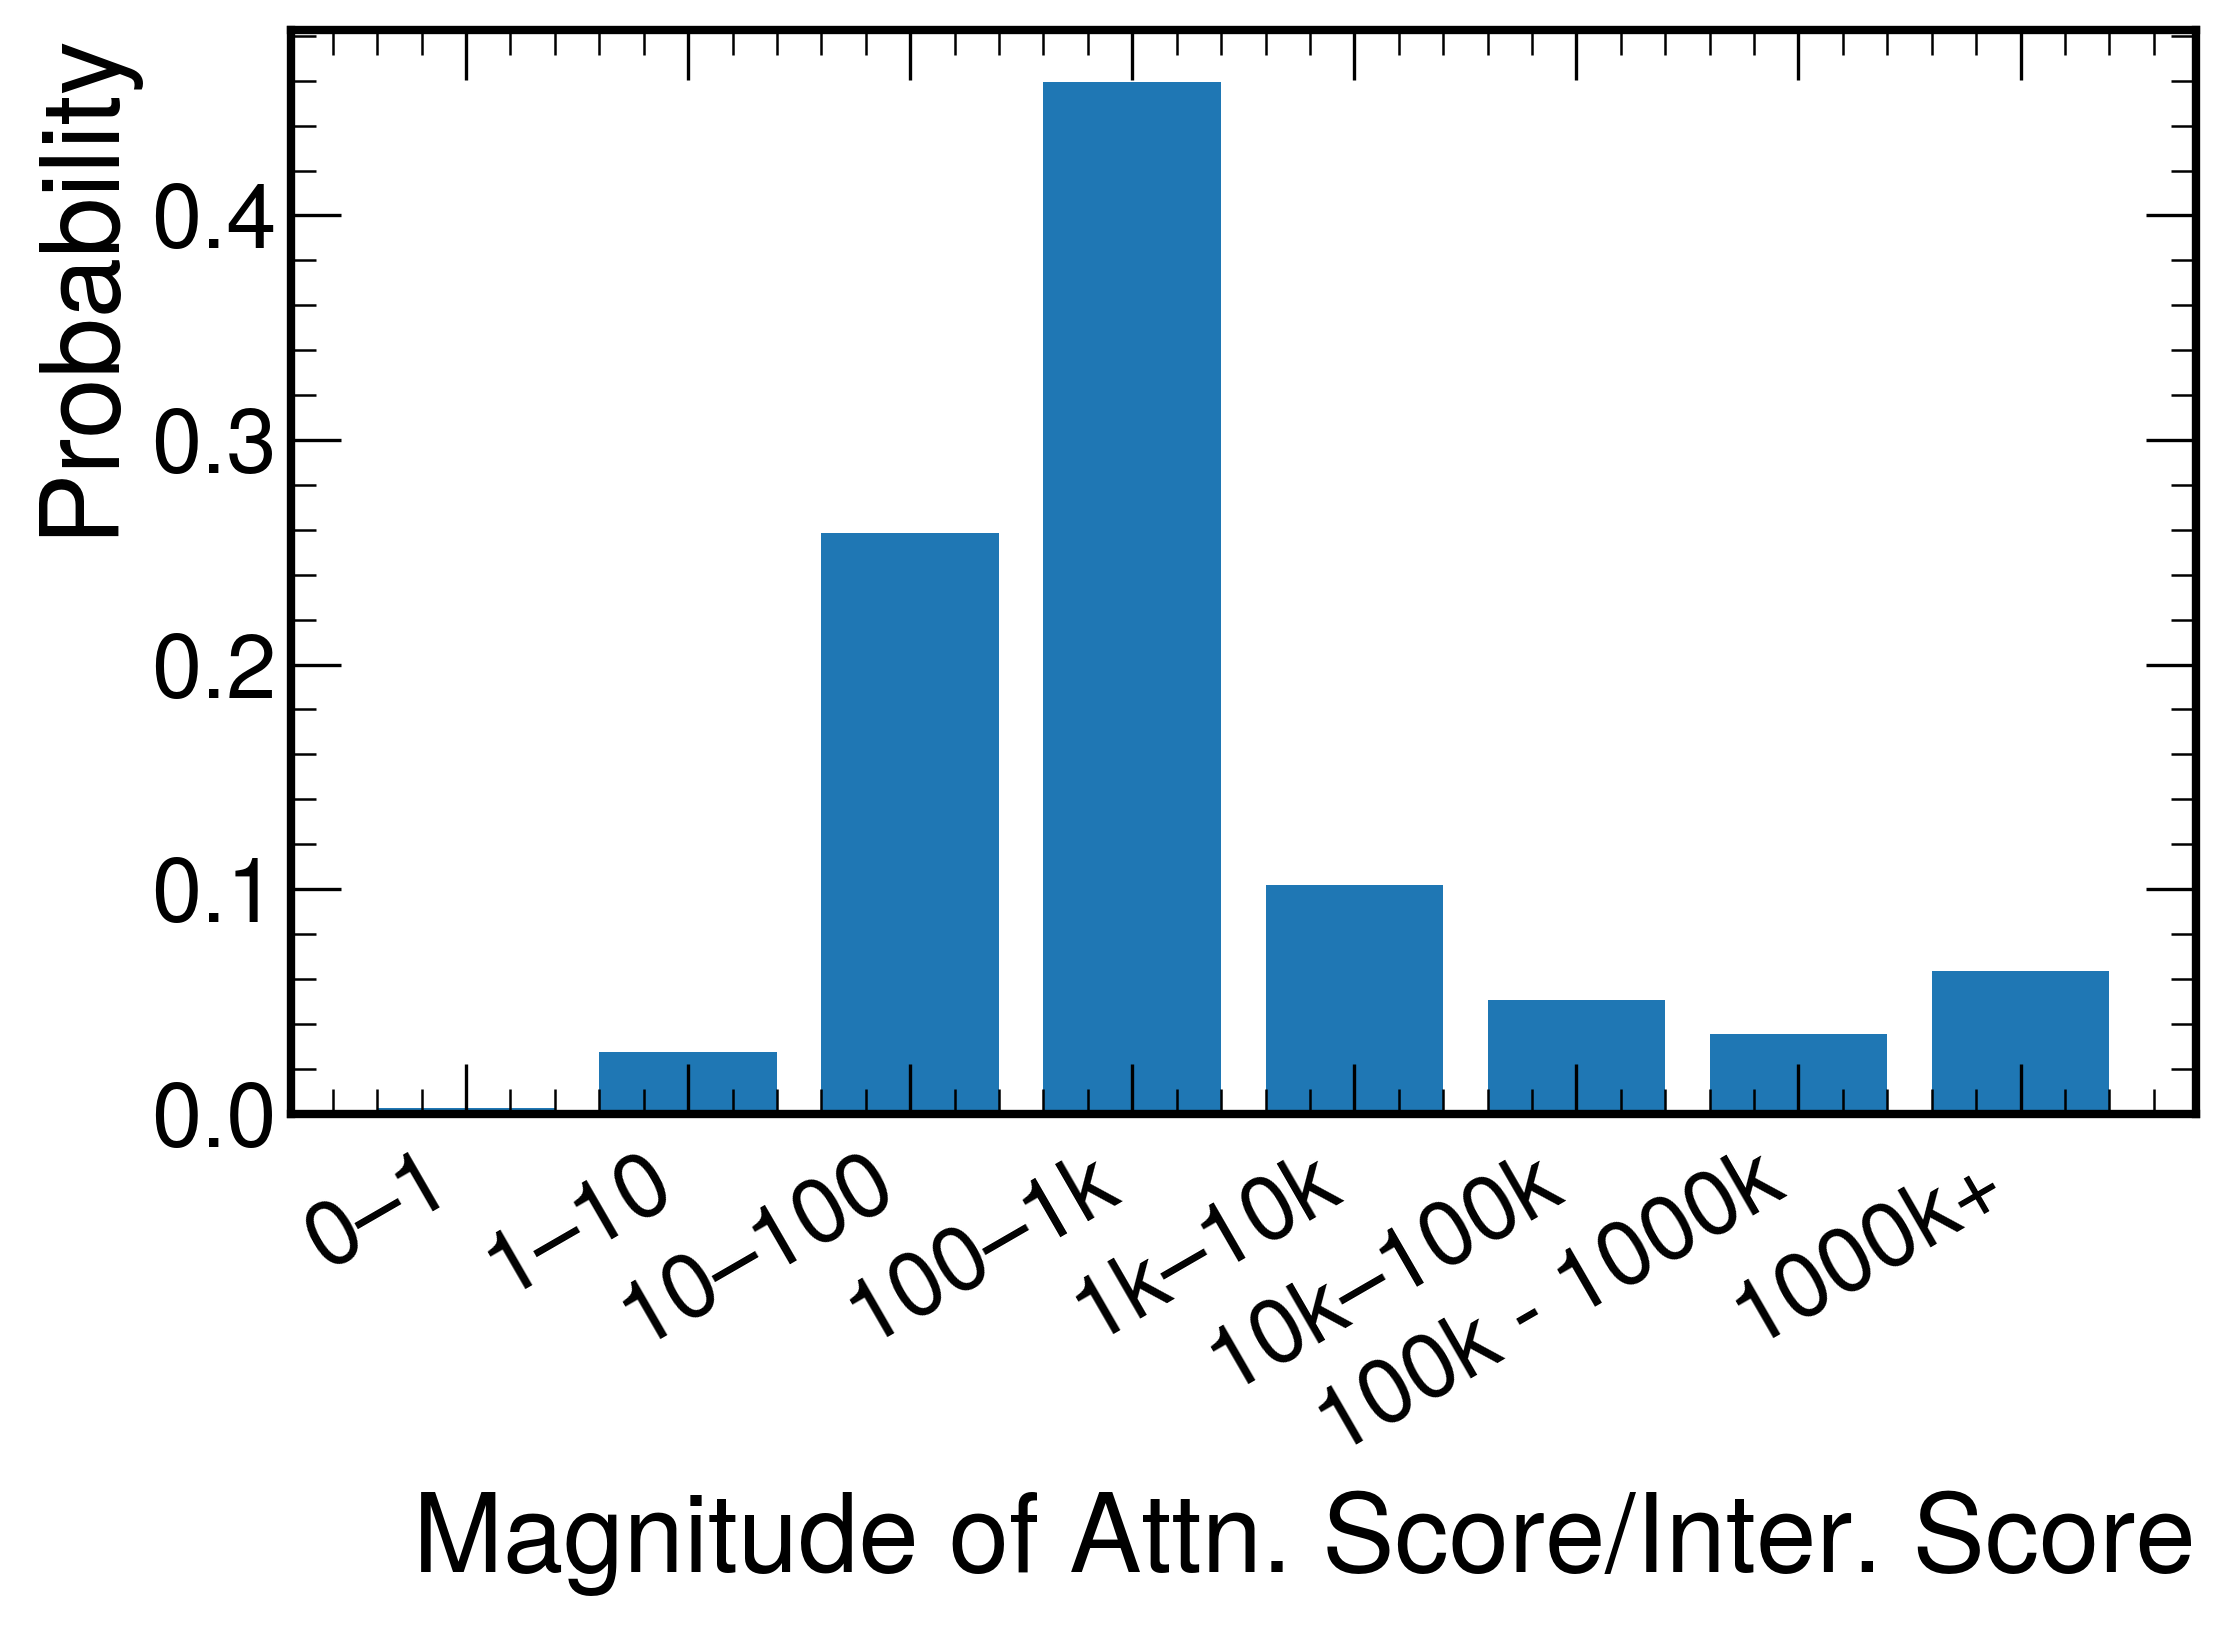

JC Full Plots finished!


In [13]:
# ---- Data ----
flat_jc_full_attn = jc_full_hooks.pre_softmax_attentions.numpy().flatten()
flat_jc_full_inter = jc_full_hooks.pre_softmax_interactions.numpy().flatten()

# Remove NaN/±inf
flat_jc_full_attn = flat_jc_full_attn[np.isfinite(flat_jc_full_attn)]
flat_jc_full_inter = flat_jc_full_inter[np.isfinite(flat_jc_full_inter)]

# ---- Align & compute magnitude ratio |attn| / |inter| ----
min_len = min(len(flat_jc_full_attn), len(flat_jc_full_inter))
attn_abs  = np.abs(flat_jc_full_attn[:min_len])
inter_abs = np.abs(flat_jc_full_inter[:min_len])

# Avoid divide-by-zero and non-finite values
mask = (inter_abs > 0) & np.isfinite(attn_abs) & np.isfinite(inter_abs)
ratio = attn_abs[mask] / inter_abs[mask]

# ---- Plot ----
num_bins = 10
weights = np.ones_like(ratio) / ratio.size  # bars sum to 1 across bins

bin_edges = [0, 1, 10, 100, 1000, 10000, 100000, 1000000, np.inf]

# ---- Histogram with probability normalization ----
counts, edges = np.histogram(ratio, bins=bin_edges)
probabilities = counts / counts.sum()

# ---- Labels (must be length bins-1 = 7) ----
labels = ["0–1", "1–10", "10–100", "100–1k", "1k–10k", "10k–100k", "100k - 1000k", "1000k+"]

# ---- Plot ----
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
x = np.arange(len(probabilities))
ax.bar(x, probabilities)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha="right")

ax.set_ylabel("Probability")
ax.set_xlabel("Magnitude of Attn. Score/Inter. Score")

ax.margins(y=0.05)  

plt.tight_layout()

out_path = './jc_full_AttnBar.pdf'

#plt.savefig(out_path, bbox_inches="tight")
plt.show()
print('JC Full Plots finished!')